# Assignment 6: Building Your First Neural Network

**Student Name:** [Your Name Here]

**Date:** [Date]

---

## Assignment Overview

You'll build feedforward neural networks to classify human activities from sensor data. You'll experiment with different architectures, compare performance against Unit 7's PCA+Random Forest approach, and learn when neural networks justify their added complexity.

---

## Step 1: Import Libraries and Load Data

In [23]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


In [24]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✓ Libraries imported successfully
TensorFlow version: 2.21.0


In [25]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df =pd.read_csv('data/train.csv')   # Replace with pd.read_csv()
test_df = pd.read_csv('data/test.csv')   # Replace with pd.read_csv()

# TODO: Separate features from labels
# The 'Activity' column contains the labels (1-6)
X_train = train_df.drop('Activity', axis=1).values
y_train = train_df['Activity'].values
X_test = test_df.drop('Activity', axis=1).values
y_test = test_df['Activity'].values

# Encode string labels to integers (0-5)
# Neural networks need numerical labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of activities: {len(np.unique(y_train))}")
print(f"Activity labels range: {y_train.min()} to {y_train.max()}")
print(f"Activity classes: {label_encoder.classes_}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Number of activities: 6
Activity labels range: 0 to 5
Activity classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


### Standardize Features

Neural networks learn best when features are normalized to similar scales

In [26]:
# TODO: Use StandardScaler to normalize features
# Fit on training data, transform both train and test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Replace with scaled training data
X_test_scaled = scaler.transform(X_test)   # Replace with scaled test data

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Mean of scaled features: {X_train_scaled.mean():.6f}")
print(f"Std of scaled features: {X_train_scaled.std():.6f}")
print("="*80)


CHECKPOINT: Features Standardized
Mean of scaled features: 0.000000
Std of scaled features: 1.000000


---
## Step 2: Build and Train Baseline Neural Network

### Create Baseline Architecture (1 Hidden Layer)

In [27]:
# TODO: Build a Sequential model with:
# - Input layer: Dense(64, activation='relu', input_shape=(562,))
# - Output layer: Dense(6, activation='softmax')

baseline_model =  keras.Sequential([layers.Dense(64, activation='relu', input_shape=(562,)),layers.Dense(6, activation='softmax')])  # Replace with your model

# TODO: Compile the model with:
# - optimizer='adam'
# - loss='sparse_categorical_crossentropy'
# - metrics=['accuracy']
baseline_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Display model architecture
if baseline_model is not None:
    baseline_model.summary()
else:
    print("Model not created yet")

c:\Users\kgmad\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 64)             │        36,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,422 (142.27 KB)

 Trainable params: 36,422 (142.27 KB)

 Non-trainable params: 0 (0.00 B)

### Train Baseline Model

In [28]:
# TODO: Train the model for 20 epochs with validation_split=0.2
# Save the training history and training time

print("Training baseline model (1 hidden layer, 64 nodes)...")
start_time = time.time()

# Your training code here
baseline_history = baseline_model.fit(X_train_scaled,y_train,epochs=20,batch_size=32,validation_split=0.2,verbose=1)  # Replace with model.fit() result

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_accuracy =baseline_model.evaluate(X_test, y_test, verbose=0)  # Replace with model.evaluate()

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print("="*80)
print(f"Architecture: 1 hidden layer, 64 nodes")
print(f"Test accuracy: {baseline_test_accuracy if baseline_test_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)

Training baseline model (1 hidden layer, 64 nodes)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8771 - loss: 0.3121 - val_accuracy: 0.9205 - val_loss: 0.2105
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9694 - loss: 0.0955 - val_accuracy: 0.9293 - val_loss: 0.1951
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9791 - loss: 0.0659 - val_accuracy: 0.9320 - val_loss: 0.1910
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9833 - loss: 0.0508 - val_accuracy: 0.9361 - val_loss: 0.2004
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9864 - loss: 0.0428 - val_accuracy: 0.9368 - val_loss: 0.2103
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9874 - loss: 0.0374 - val_accuracy: 0.9354 - val_loss: 0.2200
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9891 - loss: 0.0334 - val_accuracy: 0.9347 - val_loss: 0.2280
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

---
## Step 3: Experiment with Network Depth (Number of Layers)

### Shallow Network (1 Layer) - Already Done Above

Baseline model = 1 hidden layer with 64 nodes

### Medium Network (2 Layers)

In [29]:
# TODO: Build model with 2 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(6, activation='softmax')

medium_model =  keras.Sequential([layers.Dense(128, activation='relu', input_shape=(562,)),layers.Dense(64, activation='relu'),layers.Dense(6, activation='softmax')]) # Replace with your model

# TODO: Compile with same settings as baseline
medium_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# TODO: Train for 20 epochs with validation_split=0.2
print("Training medium network (2 hidden layers)...")
medium_history = medium_model.fit(X_train_scaled,y_train,epochs=20,validation_split=0.2,verbose=1)  # Replace with model.fit() result

# TODO: Evaluate on test set
medium_test_loss, medium_test_accuracy = medium_model.evaluate(X_test_scaled,y_test,verbose=0)

print(f"\nMedium network test accuracy: {medium_test_accuracy if medium_test_accuracy else 'Not calculated'}")

Training medium network (2 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8976 - loss: 0.2717 - val_accuracy: 0.9347 - val_loss: 0.1550
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9699 - loss: 0.0857 - val_accuracy: 0.9347 - val_loss: 0.1733
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9791 - loss: 0.0569 - val_accuracy: 0.9375 - val_loss: 0.1665
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9823 - loss: 0.0483 - val_accuracy: 0.9436 - val_loss: 0.1596
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9895 - loss: 0.0317 - val_accuracy: 0.9381 - val_loss: 0.1810
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9920 - loss: 0.0233 - val_accuracy: 0.9388 - val_loss: 0.2257
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9940 - loss: 0.0185 - val_accuracy: 0.9368 - val_loss: 0.2617
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accur

### Deep Network (3 Layers)

In [30]:
# TODO: Build model with 3 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

deep_model = keras.Sequential([layers.Dense(128, activation='relu', input_shape=(562,)),layers.Dense(64, activation='relu'),layers.Dense(32, activation='relu'),layers.Dense(6, activation='softmax')])  # Replace with your model

# TODO: Compile with same settings
deep_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# TODO: Train for 20 epochs with validation_split=0.2
print("Training deep network (3 hidden layers)...")
deep_history = deep_model.fit(X_train_scaled,y_train,epochs=20,validation_split=0.2,verbose=1)  # Replace with model.fit() result

# TODO: Evaluate on test set
deep_test_loss, deep_test_accuracy = deep_model.evaluate(X_test_scaled,y_test,verbose=0)

print(f"\nDeep network test accuracy: {deep_test_accuracy if deep_test_accuracy else 'Not calculated'}")

Training deep network (3 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8813 - loss: 0.3219 - val_accuracy: 0.9334 - val_loss: 0.1699
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9689 - loss: 0.0954 - val_accuracy: 0.9334 - val_loss: 0.1672
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9786 - loss: 0.0603 - val_accuracy: 0.9368 - val_loss: 0.1725
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9808 - loss: 0.0472 - val_accuracy: 0.9361 - val_loss: 0.1673
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9871 - loss: 0.0351 - val_accuracy: 0.9368 - val_loss: 0.1867
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9888 - loss: 0.0292 - val_accuracy: 0.9361 - val_loss: 0.2201
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9908 - loss: 0.0271 - val_accuracy: 0.9347 - val_loss: 0.2734
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accurac

### Compare Depth Experiments

In [31]:
# TODO: Create comparison of depth experiments
depth_results = pd.DataFrame({
    'Architecture': ['1 Layer (64)', '2 Layers (128, 64)', '3 Layers (128, 64, 32)'],
    'Test Accuracy': [baseline_test_accuracy, medium_test_accuracy, deep_test_accuracy]
})

print("\n" + "="*80)
print("DEPTH EXPERIMENT RESULTS")
print("="*80)
print(depth_results.to_string(index=False))
print("="*80)


DEPTH EXPERIMENT RESULTS
          Architecture  Test Accuracy
          1 Layer (64)       0.310146
    2 Layers (128, 64)       0.931116
3 Layers (128, 64, 32)       0.930777


### Reflection on Network Depth
In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does adding more layers affect performance? 
- At what point do you see diminishing returns?

[Write your response here. Consider: Did accuracy improve with each added layer? Was the improvement significant? Is there a point where adding layers doesn't help much?
Adding layers (going from 1 layer to 2)showed a significant increase in performance. However, going from 2 layers to 3 layers, the improvement rate actually became a diminishing rate. So to conclude, adding a layer didantly, help signific but three layers was not helpful.]

---
## Step 4: Experiment with Network Width (Nodes Per Layer)

### Narrow Network (2 Layers, 32 Nodes Each)

In [32]:
# TODO: Build model with 2 layers of 32 nodes each
# - Dense(32, activation='relu', input_shape=(562,))
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

narrow_model = keras.Sequential([layers.Dense(32, activation='relu', input_shape=(562,)),layers.Dense(32, activation='relu'),layers.Dense(6, activation='softmax')])  # Replace with your model

# TODO: Compile  with the same settings
narrow_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# TODO: Train for 20 epochs
print("Training narrow network (2 layers, 32 nodes each)...")
narrow_history = narrow_model.fit(X_train_scaled,y_train,epochs=20,validation_split=0.2,verbose=1)

# TODO: Evaluate
narrow_test_loss, narrow_test_accuracy =  narrow_model.evaluate( X_test_scaled,y_test,verbose=0)

print(f"\nNarrow network test accuracy: {narrow_test_accuracy if narrow_test_accuracy else 'Not calculated'}")

Training narrow network (2 layers, 32 nodes each)...
Epoch 1/20


c:\Users\kgmad\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8536 - loss: 0.3974 - val_accuracy: 0.9184 - val_loss: 0.1945
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9629 - loss: 0.1078 - val_accuracy: 0.9341 - val_loss: 0.1714
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.0707 - val_accuracy: 0.9368 - val_loss: 0.1714
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0538 - val_accuracy: 0.9395 - val_loss: 0.1701
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9855 - loss: 0.0436 - val_accuracy: 0.9334 - val_loss: 0.1834
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9879 - loss: 0.0372 - val_accuracy: 0.9409 - val_loss: 0.1778
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9896 - loss: 0.0336 - val_accuracy: 0.9388 - val_loss: 0.1939
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9900 - loss: 0.0313 - val_accuracy: 0.9375 - val_

### Medium Width Network (2 Layers, 64 Nodes Each)

In [33]:
# TODO: Build model with 2 layers of 64 nodes each
medium_width_model = keras.Sequential([layers.Dense(64, activation='relu', input_shape=(562,)),layers.Dense(64, activation='relu'),layers.Dense(6, activation='softmax')])

# TODO: Compile  with the same settings
medium_width_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# TODO: Train for 20 epochs and 64 nodes
print("Training medium-width network (2 layers, 64 nodes each)...")
medium_width_history = medium_width_model.fit(X_train_scaled,y_train,epochs=20,validation_split=0.2,verbose=1)

# TODO: Evaluate
medium_width_test_loss, medium_width_test_accuracy = medium_width_model.evaluate(X_test_scaled,y_test,verbose=0)

print(f"\nMedium-width network test accuracy: {medium_width_test_accuracy if medium_width_test_accuracy else 'Not calculated'}")

Training medium-width network (2 layers, 64 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8738 - loss: 0.3259 - val_accuracy: 0.9279 - val_loss: 0.1617
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9687 - loss: 0.0923 - val_accuracy: 0.9334 - val_loss: 0.1600
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9779 - loss: 0.0628 - val_accuracy: 0.9347 - val_loss: 0.1581
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9801 - loss: 0.0515 - val_accuracy: 0.9422 - val_loss: 0.1583
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9859 - loss: 0.0361 - val_accuracy: 0.9422 - val_loss: 0.1839
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9893 - loss: 0.0316 - val_accuracy: 0.9334 - val_loss: 0.2135
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9905 - loss: 0.0274 - val_accuracy: 0.9368 - val_loss: 0.2185
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3m

### Wide Network (2 Layers, 128 Nodes Each)

In [34]:
# TODO: Build model with 2 layers of 128 nodes each
wide_model = keras.Sequential([layers.Dense(128, activation='relu', input_shape=(562,)),layers.Dense(128, activation='relu'),layers.Dense(6, activation='softmax')])


# TODO: Compile  with the same settings
wide_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# TODO: Train the model
print("Training wide network (2 layers, 128 nodes each)...")
wide_history = wide_model.fit( X_train_scaled, y_train, epochs=20, validation_split=0.2, verbose=1)

# TODO: Evaluate
wide_test_loss, wide_test_accuracy = wide_model.evaluate(X_test_scaled,y_test,verbose=0)

print(f"\nWide network test accuracy: {wide_test_accuracy if wide_test_accuracy else 'Not calculated'}")

Training wide network (2 layers, 128 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8988 - loss: 0.2652 - val_accuracy: 0.9245 - val_loss: 0.2018
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9701 - loss: 0.0808 - val_accuracy: 0.9327 - val_loss: 0.1702
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9755 - loss: 0.0696 - val_accuracy: 0.9157 - val_loss: 0.2189
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9804 - loss: 0.0502 - val_accuracy: 0.9341 - val_loss: 0.1875
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9884 - loss: 0.0323 - val_accuracy: 0.9334 - val_loss: 0.2023
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9920 - loss: 0.0260 - val_accuracy: 0.9368 - val_loss: 0.2022
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9922 - loss: 0.0218 - val_accuracy: 0.9395 - val_loss: 0.2432
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 

### Compare Width Experiments

In [35]:
# TODO: Create comparison of width experiments
width_results = pd.DataFrame({
    'Architecture': ['2 Layers (32 each)', '2 Layers (64 each)', '2 Layers (128 each)'],
    'Test Accuracy': [narrow_test_accuracy, medium_width_test_accuracy, wide_test_accuracy]
})

print("\n" + "="*80)
print("WIDTH EXPERIMENT RESULTS")
print("="*80)
print(width_results.to_string(index=False))
print("="*80)


WIDTH EXPERIMENT RESULTS
       Architecture  Test Accuracy
 2 Layers (32 each)       0.927723
 2 Layers (64 each)       0.927384
2 Layers (128 each)       0.929420


### Reflection on Network Width

In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does increasing nodes per layer affect performance? 
- Is there a point where adding more nodes doesn't help?

[ Increasing the nodes in this case diminished the test accuracy results. Adding thee wider layers improved accuracy rather than the depth, medium and narrow results.
    
]

---
## Step 5: Train Best Architecture and Visualize Learning

### Identify and Train Best Architecture

In [36]:
# TODO: Based on your experiments above, build your best-performing architecture
# Train it for 30 epochs (longer training often improves performance)

best_model = keras.Sequential([layers.Dense(128, activation='relu', input_shape=(562,)),layers.Dense(64, activation='relu'),layers.Dense(32, activation='relu'),layers.Dense(6, activation='softmax')])
  # Replace with your best architecture

# TODO: Compile the model
best_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

print("Training best model for 30 epochs...")
start_time = time.time()

# TODO: Train for 30 epochs with validation_split=0.2
best_history = best_model.fit(X_train_scaled,y_train,epochs=30,validation_split=0.2,verbose=1)  # Replace with model.fit() result

best_time = time.time() - start_time

# TODO: Evaluate on test set
best_test_loss, best_test_accuracy = best_model.evaluate(X_test_scaled,y_test,verbose=0)

print("\n" + "="*80)
print("BEST MODEL RESULTS")
print("="*80)
print(f"Architecture: [Describe your architecture here]")
print(f"Test accuracy: {best_test_accuracy if best_test_accuracy else 'Not calculated'}")
print(f"Training time: {best_time:.2f} seconds")
print("="*80)

Training best model for 30 epochs...
Epoch 1/30


c:\Users\kgmad\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8791 - loss: 0.3108 - val_accuracy: 0.9497 - val_loss: 0.1139
Epoch 2/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9668 - loss: 0.0894 - val_accuracy: 0.9470 - val_loss: 0.1342
Epoch 3/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9764 - loss: 0.0666 - val_accuracy: 0.9402 - val_loss: 0.1408
Epoch 4/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9832 - loss: 0.0443 - val_accuracy: 0.9436 - val_loss: 0.1399
Epoch 5/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9872 - loss: 0.0343 - val_accuracy: 0.9422 - val_loss: 0.1555
Epoch 6/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9908 - loss: 0.0264 - val_accuracy: 0.9375 - val_loss: 0.1833
Epoch 7/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9942 - loss: 0.0212 - val_accuracy: 0.9395 - val_loss: 0.2004
Epoch 8/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9905 - loss: 0.0308 - val_accuracy: 0.9354 - val_

### Visualize Training Progress - Accuracy

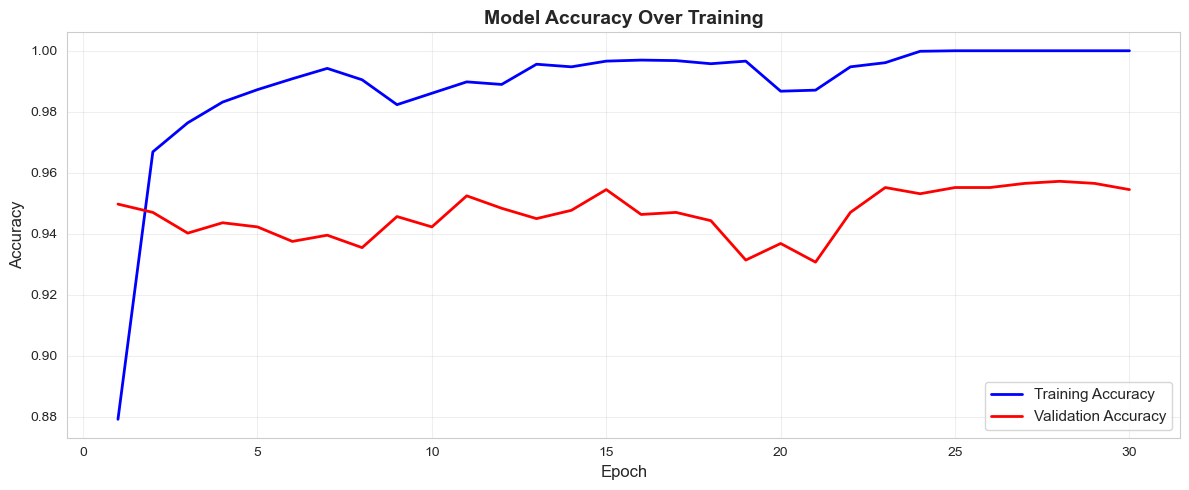

In [37]:
# TODO: Plot training accuracy vs validation accuracy over epochs
# Use best_history.history['accuracy'] and best_history.history['val_accuracy']
train_accuracy = best_history.history['accuracy']
val_accuracy = best_history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)

if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    # Your plotting code here
    plt.plot(epochs, train_accuracy, 'b-', linewidth=2, label='Training Accuracy')
    plt.plot(epochs, val_accuracy, 'r-', linewidth=2, label='Validation Accuracy')
    plt.title('Model Accuracy Over Training', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Train best model first to visualize results")

### Visualize Training Progress - Loss

<Figure size 1200x500 with 0 Axes>

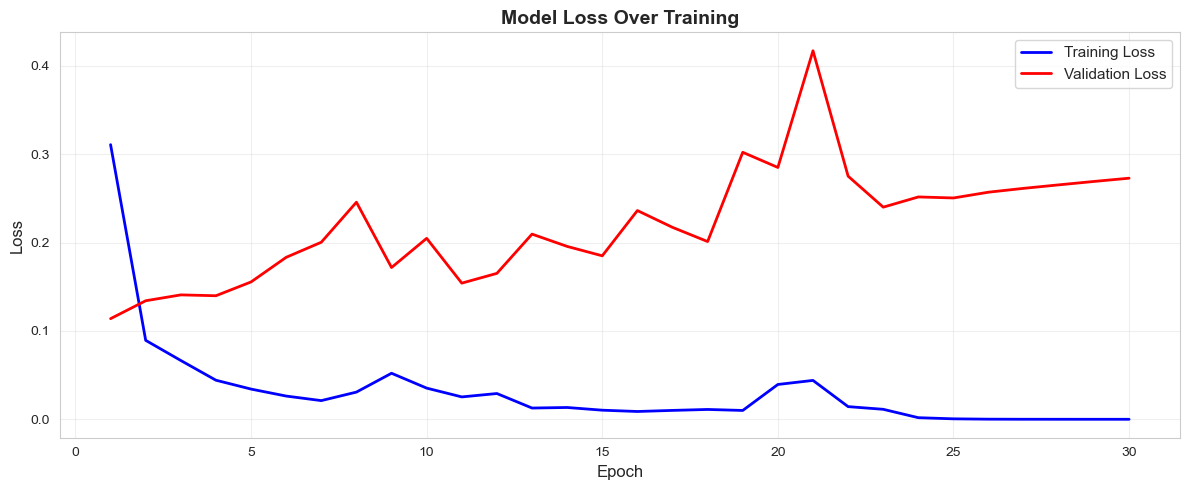

In [38]:
# TODO: Plot training loss vs validation loss over epochs
# Use best_history.history['loss'] and best_history.history['val_loss']

if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    # Your plotting code here
    train_loss = best_history.history['loss']
    val_loss = best_history.history['val_loss']
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12,5))

    plt.plot(epochs, train_loss, 'b-', linewidth=2, label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', linewidth=2, label='Validation Loss')

    plt.title('Model Loss Over Training', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Train best model first to visualize results")

---
## Step 6: Compare Against Unit 7 PCA + Random Forest

In [39]:
# TODO: Enter your Unit 7 PCA+Random Forest results here
# You should have recorded these in Unit 7
unit7_pca_rf_accuracy = 0.863590  # Replace with your Unit 7 test accuracy
unit7_pca_rf_time = 3.823929   # Replace with your Unit 7 training time (if you have it)

# Create comparison table
comparison = pd.DataFrame({
    'Model': [
        'Baseline NN (1 layer, 64 nodes)',
        'Best NN (Your Architecture)',
        'Unit 7: PCA + Random Forest'
    ],
    'Features/Layers': [
        '1 hidden layer',
        '[Describe your architecture]',
        '26 PCA components'
    ],
    'Test Accuracy': [
        baseline_test_accuracy,
        best_test_accuracy,
        unit7_pca_rf_accuracy
    ],
    'Training Time': [
        f"{baseline_time:.2f}s" if baseline_time else 'N/A',
        f"{best_time:.2f}s" if best_time else 'N/A',
        f"{unit7_pca_rf_time:.2f}s" if unit7_pca_rf_time else 'N/A'
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)


MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7
                          Model              Features/Layers  Test Accuracy Training Time
Baseline NN (1 layer, 64 nodes)               1 hidden layer       0.310146        12.56s
    Best NN (Your Architecture) [Describe your architecture]       0.934170        20.67s
    Unit 7: PCA + Random Forest            26 PCA components       0.863590         3.82s


### Reflection on Neural Network vs PCA+Random Forest
In the Markdown cell, write 2-3 sentences that answer the following questions:
- How does your best neural network compare to PCA+Random Forest?
- Did the neural network's ability to learn its own features from raw sensor data lead to better performance than manually engineering features with PCA? (2-3 sentences)

[Write your response here. Consider: Which approach achieved higher accuracy? Was the difference significant? What are the tradeoffs in complexity, training time, and interpretability?
The best Neural network compared to the random forest by being slightly more accurate. The ability for Neural network to learn its own features from raw sensor data led to a slightly better performance due to the ability of forming and identifying more rekationships.]

---
## Step 7: Reflect on When to Use Neural Networks

### When to Use Neural Networks vs Simpler Models

In the Markdown cell below, write 3-4 sentences addressing the following: 
- Based on your results and what you learned in the resources, when should you use neural networks versus simpler models like random forests? Consider factors like data type (sensor data, images, text vs tabular business data), dataset size, interpretability needs, and performance requirements. 
- Give at least one example of when you'd choose neural networks and one example of when you'd choose random forests

[Write your response here. Think about:
- What types of data are neural networks best for? (images, sensor data, text vs tabular business data)
- When do neural networks justify their added complexity and training time?
- When would simpler models like random forests be more appropriate?
- Give concrete examples of problems where you'd choose each approach
Neural networks are most likely best for larger and more complex datasets like images, sensor data, uadio and text. This is because, NN can identify more complex patterns with its own raw sensor data. A specific example of when i would use neural networks would be when doing facial recognition in because it can find patterns and identfiy images faster and better. I would use a simpler model like random forests specifically when working in retail and tring to predict sales,or  customer retention ]


---
## Step 8: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline neural network trained and evaluated
   - At least 3 depth experiments (1, 2, 3 layers)
   - At least 3 width experiments (32, 64, 128 nodes)
   - Best model trained for 30 epochs with accuracy and loss plots
   - Comparison table with baseline NN, best NN, and Unit 7 PCA+RF
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed neural networks assignment'
git push
```

Submit your GitHub repository link on the course platform.